قراءة البيانات

In [ ]:
# حل الطالبه اسيل ماهر الرحيلي 
#F6
# رقم الجامعي 4454054
import pandas as pd
import matplotlib.pyplot as plt

# قراءة البيانات
data = pd.read_csv('height_weight.csv')

# عرض البيانات للتأكد
print(data)


   Weight  Height
0      50     152
1      60     165
2      65     168
3      70     174
4      85     186


رسم العلاقة بين الوزن والطول

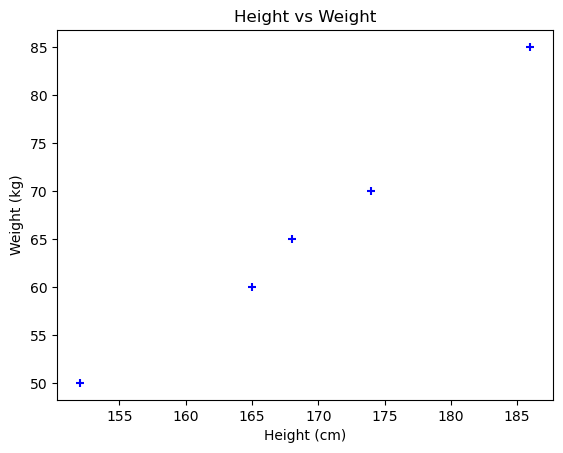

In [22]:
plt.scatter(data['Height'], data['Weight'], color='blue',marker='+')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Height vs Weight')
plt.show()

دالة الفرضية (Hypothesis Function)

In [11]:
import numpy as np
 #نحول الأعمدة إلى numpy arrays
X = data['Weight'].values
Y = data['Height'].values
#فرض قيم اولية للمعاملات
w0=0
w1=0
def  hypothesis(X,w0,w1):
    return w0 + w1 * X
#التقاطع +الميل *الوزن 
# التقاطع هوا النقطه التي يقطه فيها الخط محور الصادات عند وزن معين(Y)
#الميل هوا مقدار التغير في الطول  مقابل كل تفير في الوزن (X)
print(hypothesis(70,w0,w1))  # اختبار الدالة مع وزن 70 كجم

0


راح يطلع الناتج صفر لأن المعاملات كلها صفر — وهذا طبيعي الآن.
بعدين راح نبدأ نحدث القيم باستخدام الانحدار التدرّجي (gradient descent).

دالة الخطأ (Mean Absolute Error)

In [12]:
def MAE(x, y, w0, w1):
    m = len(x)
    total_error = 0
    for i in range(m):
        total_error += abs(hypothesis(x[i], w0, w1) - y[i])
    return total_error / m
print(MAE(X, Y, w0, w1))  # اختبار دالة MAE مع القيم الأولية للمعاملات

169.0


عندنا خطأ (MAE).

هدفنا نغيّر القيم 𝑤0,𝑤1
	​عشان هذا الخطأ يصير أصغر وأصغر.
وهذا بالضبط شغل خوارزمية الانحدار التدرّجي (Gradient Descent) 
فكرتها مثل إنك تمشي في طريق فيه “انحدار”،
كل مرة تخطو خطوة صغيرة نحو الاتجاه اللي يقلل الخطأ أكثر.

تنفيذ الخوارزميه
 الهدف اوجد طول الانسان من خلال وزنه

In [17]:
def gradient_descent(X, Y, w0, w1, alpha, iterations):
    n = len(X)
    losses = []

    for _ in range(iterations):
        m = 0
        b = 0
        #هذول تفاضلات المعادلة الي بيحركولي الخط لأفضل مكان
        for i in range(n):
            y_pred = hypothesis(X[i], w0, w1)
            error = y_pred - Y[i]
            sign = 1 if error > 0 else -1 if error < 0 else 0
            m+= sign
            b+= sign * X[i]
        
        # نحسب المتوسط
        m /= n
        b /= n

        # نحدّث القيم
        w0 = w0 - alpha * m
        w1 = w1 - alpha * b

        # نحسب الخطأ ونخزنه عشان نرسمه لاحقاً
        loss = MAE(X, Y, w0, w1)
        losses.append(loss)

    return w0, w1, losses


Evaluate the mode

In [19]:
w0, w1, losses = gradient_descent(X, Y, w0, w1, alpha=0.01, iterations=1000)
final_mae = MAE(X, Y, w0, w1)

print("Final MAE after training =", final_mae)


Final MAE after training = 14.471960000000422


Plot the fitted regression line

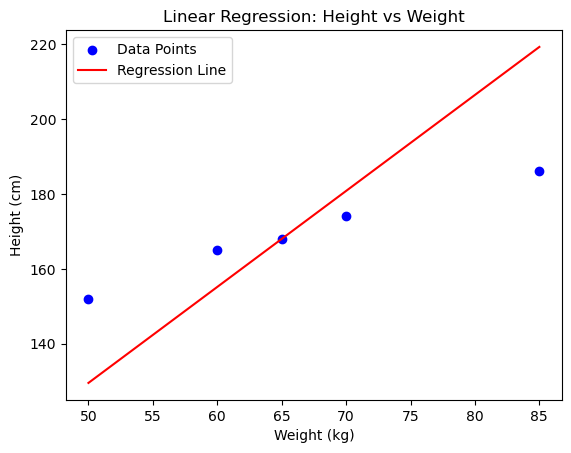

In [20]:
plt.scatter(X,Y,color='blue',label='Data Points'    )

y_pred_line = hypothesis(X, w0, w1)
plt.plot(X, y_pred_line, color='red', label='Regression Line')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.title('Linear Regression: Height vs Weight')
plt.legend()
plt.show()

Predict the height for 72 kg person

In [21]:
predicted_height = hypothesis(70, w0, w1)
print("Predicted height for weight 70 kg =", predicted_height)

Predicted height for weight 70 kg = 180.8101999999927
